In [2]:
import sys
sys.path.append('../')
from utils_models import *

In [49]:

with open('../pickles/magic_compu_1em3_relabel.pkl', 'rb') as file:
    results_compu_1em3 = pickle.load(file)


In [65]:
results_compu_1em3[-1].states_dressed_to_2_level_dm[0]

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 0.]
 [1. 0.]]

In [64]:
one * zero.dag()

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[0. 0.]
 [1. 0.]]

# filter out the negative signs

In [3]:
max_ql = 21
max_ol = 98

system = FluxoniumOscillatorSystem(
    EJ = 2.75,
    EC = 0.6,
    EL = 0.13,
    Er = 7.20701708,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(40) ],
    computaional_states = '1,2',
    )



In [5]:
dressed_idxes_with_negative_sign = []
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
for i in range(system.hilbertspace.dimension):
    arr = np.array(evecs[i])
    max_abs_index = np.argmax(np.abs(arr))
    max_abs_value = arr[max_abs_index]
    if max_abs_value > 0:
        pass
    elif max_abs_value < 0:
        dressed_idxes_with_negative_sign.append(i)

# redo truncation

In [26]:

def dressed_to_2_level_dm(dressed_dm: qutip.Qobj, 
                        product_to_dressed: dict, 
                        qbt_position: int,
                        computational_0: int,
                        computational_1: int,
                        products_to_keep=None,
                        dressed_idxes_with_negative_sign: List[int] = None,
                        ) -> qutip.Qobj:
    """
    Convert a dressed density matrix to a multi-level density matrix for specified computational states,
    inferring subsystem dimensions from product_to_dressed.

    Parameters:
    - dressed_dm: The dressed density matrix as a qutip.Qobj.
    - product_to_dressed: Mapping from product states to dressed states indices.
    - qbt_position: which of the subsystem is the qubit
    - computational_0, computational_1: indicate which two levels of the qubit are the computational states.
    - products_to_keep: Optional list of product states to keep.

    Returns:
    - qutip.Qobj representing the reduced density matrix for specified computational states.
    """
    dressed_dm_data = pad_back_custom(dressed_dm, products_to_keep, product_to_dressed)
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    # Filter and adjust product_to_dressed
    filtered_product_to_dressed = {}
    for product_state, dressed_index in product_to_dressed.items():
        if product_state[qbt_position] in (computational_0, computational_1):
            new_product_state = list(product_state)
            new_product_state[qbt_position] = 0 if product_state[qbt_position] == computational_0 else 1
            filtered_product_to_dressed[tuple(new_product_state)] = dressed_index

    # Convert dressed_idxes_with_negative_sign to a set for O(1) lookup
    dressed_idxes_with_negative_sign_set = set(dressed_idxes_with_negative_sign)

    # Pre-compute the sign multiplier for each dressed index
    sign_multiplier = {idx: -1 if idx in dressed_idxes_with_negative_sign_set else 1
                    for idx in filtered_product_to_dressed.values()}



    # Infer subsystem dimensions
    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
    subsystem_dims[qbt_position] = 2
    rho_product = np.zeros((subsystem_dims*2), dtype=complex)
    for product_state, dressed_index1 in filtered_product_to_dressed.items():
        for product_state2, dressed_index2 in filtered_product_to_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element

    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])

    rho_2_level = rho_product.ptrace(qbt_position)
    return rho_2_level



In [1]:
for result in results_compu_1em3:
    result.new_2_lvl = [dressed_to_2_level_dm(dressed_dm  = state, 
                        product_to_dressed = system.product_to_dressed, 
                        qbt_position = 0,
                        computational_0 = 1,
                        computational_1 = 2,
                        products_to_keep = None,
                        dressed_idxes_with_negative_sign = dressed_idxes_with_negative_sign,
                        ) for state in tqdm(result.states_pad_back_custom, desc=f"Processing")]
    
    

In [29]:
# import pickle
# with open('../pickles/magic_compu_1em3_relabel.pkl', 'wb') as file:
#     pickle.dump(results_compu_1em3, file)

Text(0.5, 0, 't (ns)')

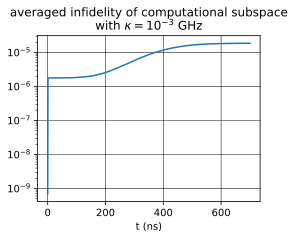

In [110]:
num_time_steps = len(results_compu_1em3[0].times)
tlist = results_compu_1em3[0].times


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero -  one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


# from scipy.optimize import minimize

# infidelity1 = []
# phase_lump = []
# for idx in tqdm(range(num_time_steps)):
#     dms = [result.new_2_lvl[idx] for result in results_compu_1em3]
#     def objective_function(phase):
#         return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
#     initial_phase = [0.0]
#     bounds = [(0, 2 * 3.141592653589793)]
#     opt_result = minimize(objective_function, initial_phase,method="COBYLA")
#     infidelity1.append(opt_result.fun)
#     phase_lump.append(opt_result.x[0])


plt.figure(figsize = (4,3))

plt.plot(tlist,infidelity1,label = rf'$\kappa = 10^{-3}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
# plt.minorticks_on()
# plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

# plt.legend()

plt.yscale('log')
plt.title(rf"""averaged infidelity of computational subspace
with $\kappa = 10^{{-3}}$ GHz""")
plt.xlabel("t (ns)")

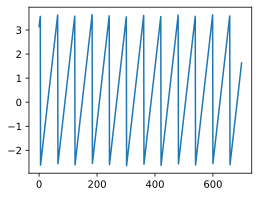

In [68]:
plt.figure(figsize = (4,3))
plt.plot(phase_lump)

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook/__init__.py: 1335

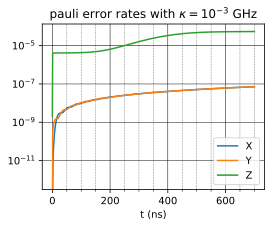

In [106]:
# # colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
# # linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
# tlist = results_compu_1em3[0].times

# times = tlist

# pauli_results = [results_compu_1em3[0],results_compu_1em3[1],results_compu_1em3[-2],results_compu_1em3[-1]] 
# phase = phase_lump

# errors = {
#     'X': [],
#     'Y': [],
#     'Z': []
# }
# inner_product_vals_dict = {
#     'X': [],
#     'Y': [],
#     'Z': []
# }

# Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]


# dms_ideal = [
#     zero * zero.dag(),
#     one * one.dag(),
#     zero * one.dag(),
#     one * zero.dag()
# ]
# for idx in tqdm(range(len(times)), desc='Processing through tlist'):
#     dms = [pauli_results[0].new_2_lvl[idx],
#         pauli_results[1].new_2_lvl[idx],
#         pauli_results[2].new_2_lvl[idx],
#         pauli_results[3].new_2_lvl[idx]]
#     gate = qutip.qip.operations.phasegate(theta=  phase[idx])
#     for P, Pauli in zip(['X','Y','Z'],Paulis):
#         inner_product_vals = []
#         for dm_ideal, dm in zip(
#             dms_ideal,
#             dms
#             ):
#             the_second_term = Pauli * dm_ideal * Pauli.dag()                    
#             dm = gate * dm * gate.dag()
#             inner_product = (the_second_term * dm.dag()).tr()
#             inner_product_vals.append(inner_product)
#         errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
#         inner_product_vals_dict[P].append(inner_product_vals)


plt.figure(figsize = (4,3))
plt.plot(times,errors['X'],label = 'X ' )
plt.plot(times,errors['Y'],label = 'Y ' )
plt.plot(times,errors['Z'],label = 'Z ' )
plt.title("pauli error rates with " + rf'$\kappa = 10^{{-3}}$ GHz')

plt.xlabel("t (ns)")
plt.yscale('log')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()


# 

In [34]:
subsystem_dims = [max(indexes) + 1 for indexes in zip(*system.product_to_dressed.keys())]
# Precompute indices as before
prod_dims_cumprod = np.cumprod(subsystem_dims[::-1])[::-1]
prod_dims_cumprod_shifted = np.roll(prod_dims_cumprod, shift=-1)
prod_dims_cumprod_shifted[-1] = 1

# Assuming product_to_dressed keys are tuples like (ql, ol), compute the index for each product state
indices_map = {pstate: sum(np.array(pstate) * prod_dims_cumprod_shifted) for pstate in system.product_to_dressed.keys()}


# Convert dressed_idxes_with_negative_sign to a set for O(1) lookup
dressed_idxes_with_negative_sign_set = set(dressed_idxes_with_negative_sign)
# Pre-compute the sign multiplier for each dressed index
sign_multiplier = {idx: -1 if idx in dressed_idxes_with_negative_sign_set else 1
                for idx in system.product_to_dressed.values()}

def convert_to_product(dm):
    if dm.isket:
        dm = qutip.ket2dm(dm)
    dressed_dm_data = dm.full()
    rho_product = np.zeros((np.prod(subsystem_dims), np.prod(subsystem_dims)), dtype=complex)

    # Now, instead of iterating and unpacking, directly use the dressed indices
    for product_state, dressed_index1 in system.product_to_dressed.items():
        index1 = indices_map[product_state]  # Use precomputed index
        for product_state2, dressed_index2 in system.product_to_dressed.items():
            index2 = indices_map[product_state2]  # Use precomputed index
            # Extract element directly without unpacking
            element = dressed_dm_data[dressed_index1, dressed_index2]* sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[index1, index2] += element

    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product

def truncate_first_subsystem(rho):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[1:3, :, 1:3, :]
    truncated_rho_array = truncated_rho_reshaped.reshape((2 * dim_2, 2 * dim_2))
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[2, dim_2], [2, dim_2]])
    return truncated_rho



def truncate_second_subsystem(rho,n):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    if n >= dim_2:
        raise ValueError("n is out of bounds for the dimensionality of the second subsystem.")
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[:, n:n+1, :, n:n+1]
    # Reshape back to 2D array
    truncated_rho_array = truncated_rho_reshaped.reshape((dim_1, dim_1))
    # Create a new Qobj from the truncated array, adjusting the dimensions list to reflect the truncation
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[dim_1], [dim_1]])
    return truncated_rho


In [35]:

class WeightedInfidelityCalculatorV2:
    def __init__(self):
        self.cache = {}

    def _cache_key(self, rho):
        return (id(rho))

    def _compute_pre_cached_values(self, rho):
        key = self._cache_key(rho)
        if key not in self.cache:
            rho_array = rho.full().reshape((rho.dims[0][0], rho.dims[0][1], rho.dims[0][0], rho.dims[0][1]))
            weights = np.real(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
            dim_1, dim_2  = rho.dims[0]
            self.cache[key] = (rho_array,weights,dim_1,dim_2)
        return self.cache[key]

    def calc_weighted_infidelity_with_phase(self, theta, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        
        fid_sum = 0.0
        for ol in range(len(theta)):
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[ol])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    
    def calc_infidelity_with_phase_for_single_osc_lvl(self, theta,osc_lvl, rho, state_ideal):
        rho_array,weights, dim_1, dim_2 = self._compute_pre_cached_values(rho)
        fid_sum = 0.0
        for ol in [osc_lvl]:
            gate = qutip.Qobj(np.array([[1, 0], [0, np.exp(1.0j * theta[0])]]))
            A = qutip.ket2dm(gate*state_ideal)
            sqrtmA = A.sqrtm()
            B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
            eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
            fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
            fid_sum += fid * weights[ol]
        return 1 - fid_sum
    

tot_time = results_compu_1em3[0].times[-1]
tlist = np.linspace(0, tot_time, int(tot_time))
slice_interval = 20
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)


zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero -  one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j * one).unit(),
                ]


# infidelity1 = []
phase1 = [[] for _ in range(5)]
for idx in tqdm(range(num_time_steps)):
    calculator = WeightedInfidelityCalculatorV2()
    dms = [result.states_pad_back_custom[idx*slice_interval] for result in results_compu_1em3]
    dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
    for ol in range(5):
        def objective_function(x):
            infidelities = [calculator.calc_infidelity_with_phase_for_single_osc_lvl(x,
                                                                ol,
                                                                dm_two_lvl,
                                                                state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
            mean = np.mean(infidelities)
            return mean
        x0 = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, x0,method="COBYLA")
        # infidelity1.append(opt_result.fun)
        phase1[ol].append(opt_result.x[0])


100%|██████████| 35/35 [08:45<00:00, 15.01s/it]ow/lib/python3.10/site-packages/scipy/sparse/_base.py: 653


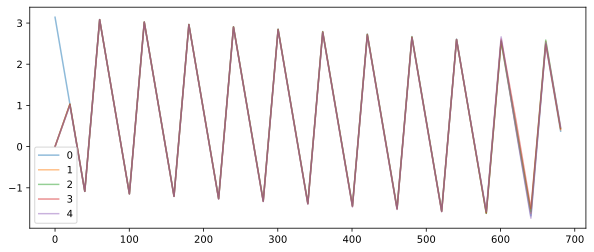

In [36]:
plt.figure(figsize=(10,4))

phase_list = np.array(phase1)
for i in range(5):
    plt.plot(new_tlist,phase_list[i],label = rf'{i}',alpha=0.5)
plt.legend()

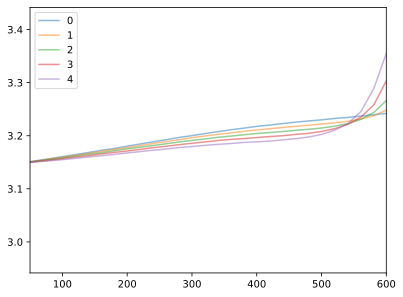

In [43]:
evals = system.qbt.eigenvals()
omega =  -1 *(evals[2]-evals[1])*2*np.pi
for i in range(5):
    resid = (np.array(phase_list[i]) - np.array(omega*new_tlist))%(2*np.pi)
    plt.plot(new_tlist,resid,label=f"{i}",alpha=0.5)
plt.ylim(np.pi-0.2,np.pi+0.3)
plt.xlim(50,600)
plt.legend()

In [73]:

with open('../pickles/magic_leak_1em3.pkl', 'rb') as file:
    results_leak = pickle.load(file)

Processing:  37%|███▋      | 261/700 [7:59:11<13:25:59, 110.16s/it]


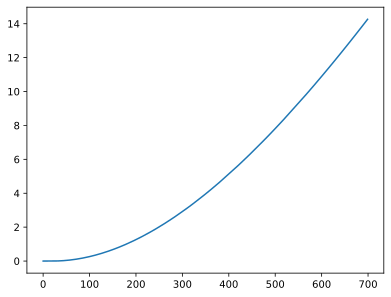

In [84]:
plt.plot(results_leak[0].expect[1])

In [95]:
last_leakage_state = convert_to_product(results_leak[0].states_pad_back_custom[-1])

In [96]:
last_compu_state = convert_to_product(results_compu_1em3[0].states_pad_back_custom[-1])

nonhermicity: Frobenius norm of the difference between rho and rho dag 1.715534827540344e-05
trace: 1.0000000000006706
nonhermicity: Frobenius norm of the difference between rho and rho dag 0.0
trace: 1.000000000002026


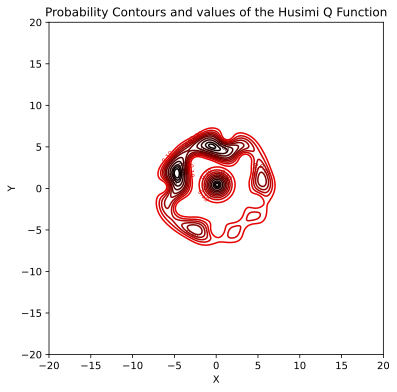

In [98]:
plt.figure(figsize=(6,6))
 
def plot_husimi_probability_contours(rho_product):
    rho_coherent = rho_product.ptrace(1)

    # print(f"nonhermicity: abs(rho_coherent - rho_coherent.dag()).data.max() {abs(rho_coherent - rho_coherent.dag()).data.max()}")
    print(f"nonhermicity: Frobenius norm of the difference between rho and rho dag {np.linalg.norm((rho_coherent - rho_coherent.dag()).full(), 'fro')}")
    rho_coherent = 0.5 * (rho_coherent + rho_coherent.dag())

    print(f"trace: {rho_coherent.tr()}")
    rho_coherent = rho_coherent / rho_coherent.tr()


    xvec = np.linspace(-20,20,500)

    Q_coherent = qutip.qfunc(rho_coherent, xvec, xvec)

    q_values = Q_coherent
    sorted_q = np.sort(q_values.ravel())
    cumulative_sum = np.cumsum(sorted_q)
    total_sum = cumulative_sum[-1]
    X, Y = np.meshgrid(xvec, xvec)
    for prob in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.05,0.02]:
        level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
        contour = plt.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
        fmt = {level_value:f'{1 - prob:.2f}'}
        plt.clabel(contour, inline=False, fontsize=6, fmt=fmt)

    # Q_coherent[Q_coherent < sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - 0.98))]] = None
    # plt.contourf(xvec, xvec, Q_coherent, 100)


plot_husimi_probability_contours(last_leakage_state)
plot_husimi_probability_contours(last_compu_state)


plt.title("Probability Contours and values of the Husimi Q Function")
plt.xlabel("X")
plt.ylabel("Y")
# plt.xlim(-8,8)
# plt.ylim(-8,8)

plt.show()